# LSTM Model Evaluation
**Multi-Class Classification: Healthy vs Inter-ictal vs Seizure**

This notebook evaluates the Deep Learning LSTM model using medical metrics. 
It saves the key performance indicators to a JSON file for easy comparison.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report
)

# Set style
sns.set(style="whitegrid")

## 1. Load Predictions
Loading the test set predictions generated by `src/training/train_lstm.py`.

In [2]:
# Check if files exist
output_dir = "../outputs"
required_files = ["lstm_y_test_true.npy", "lstm_y_test_pred.npy", "lstm_y_test_prob.npy"]

for f in required_files:
    path = os.path.join(output_dir, f)
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}. Run train_lstm.py first.")

y_true = np.load(os.path.join(output_dir, "lstm_y_test_true.npy"))
y_pred = np.load(os.path.join(output_dir, "lstm_y_test_pred.npy"))
y_prob = np.load(os.path.join(output_dir, "lstm_y_test_prob.npy"))

print(f"Loaded {len(y_true)} test samples.")

Loaded 13200 test samples.


## 2. Medical Metrics Calculation

In [3]:
# Calculate basic metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")
print(f"Macro F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Inter-ictal', 'Seizure']))

Accuracy: 0.9420
Macro Precision: 0.9479
Macro Recall: 0.9485
Macro F1-Score: 0.9474

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.91      0.97      0.94      5280
 Inter-ictal       0.96      0.89      0.93      5280
     Seizure       0.97      0.98      0.98      2640

    accuracy                           0.94     13200
   macro avg       0.95      0.95      0.95     13200
weighted avg       0.94      0.94      0.94     13200



## 3. Visualization

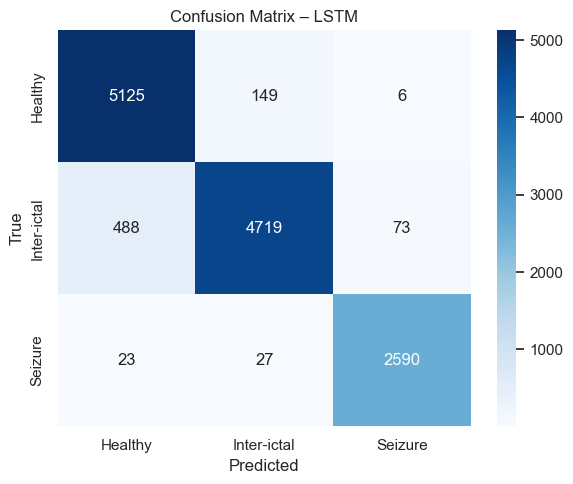

In [4]:
# Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy", "Inter-ictal", "Seizure"],
    yticklabels=["Healthy", "Inter-ictal", "Seizure"]
)
plt.title("Confusion Matrix – LSTM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 4. Save Metrics to JSON

In [5]:
metrics_data = {
    "model": "LSTM",
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "confusion_matrix": cm.tolist()
}

# Establish directory
metrics_dir = "../metrics"
if not os.path.exists(metrics_dir):
    os.makedirs(metrics_dir)

# Save to file
file_path = os.path.join(metrics_dir, "LSTM_metrics.json")
with open(file_path, "w") as f:
    json.dump(metrics_data, f, indent=4)

print(f"Metrics saved to {file_path}")

Metrics saved to ../metrics/LSTM_metrics.json
